In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv(r'C:\Users\hp\Downloads\Data_file - data_file.csv')
df

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,03-05-2021,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,05-08-2021,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,03-04-2018,Singapore,99993,1,19240,0,120,80,1,2,1,168,Doctor,1,76.0,0
69996,12-01-2022,Malaysia,99995,1,22601,0,140,90,2,1,2,158,Accountant,0,126.0,1
69997,25-08-2022,Malaysia,99996,0,19066,1,180,90,3,2,1,183,Accountant,0,105.0,1
69998,13-07-2020,Singapore,99998,0,22431,0,135,80,1,1,2,163,Accountant,0,72.0,1


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 16 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         70000 non-null  object 
 1   country      70000 non-null  object 
 2   id           70000 non-null  int64  
 3   active       70000 non-null  int64  
 4   age          70000 non-null  int64  
 5   alco         70000 non-null  int64  
 6   ap_hi        70000 non-null  int64  
 7   ap_lo        70000 non-null  int64  
 8   cholesterol  70000 non-null  int64  
 9   gender       70000 non-null  int64  
 10  gluc         70000 non-null  int64  
 11  height       70000 non-null  int64  
 12  occupation   70000 non-null  object 
 13  smoke        70000 non-null  int64  
 14  weight       70000 non-null  float64
 15  disease      70000 non-null  int64  
dtypes: float64(1), int64(12), object(3)
memory usage: 8.5+ MB


,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


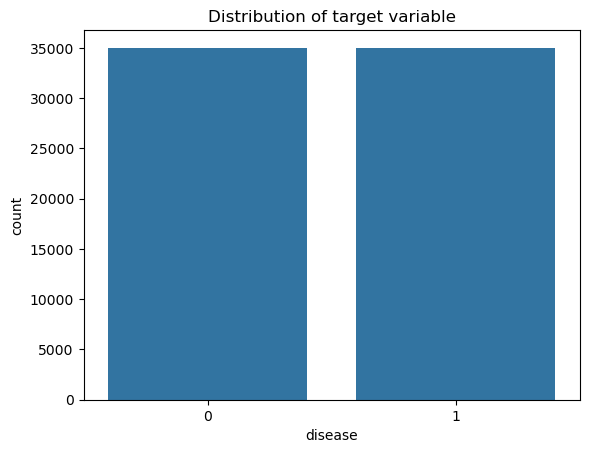

In [4]:
#distribution of target variable

sns.countplot(x = 'disease', data = df)
plt.title('Distribution of target variable')
plt.show()

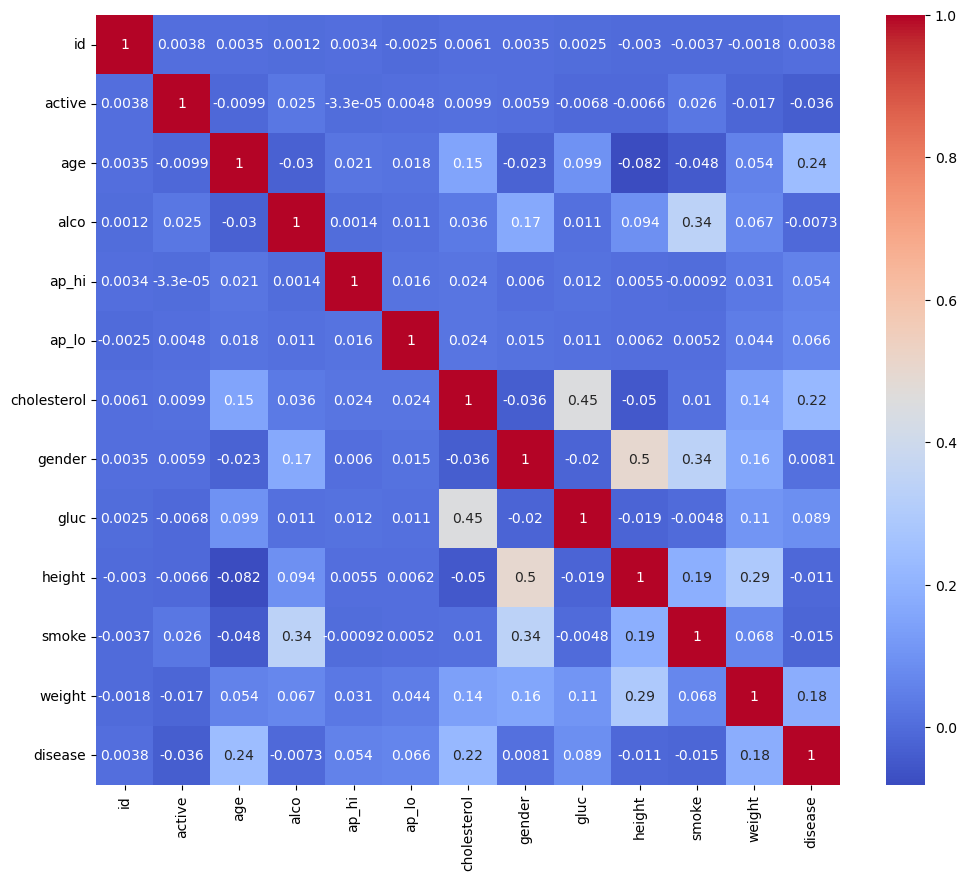

In [5]:
#filter number columns for correlation  matrix
num_cols = list()
plt.figure(figsize = (12,10))
for column in df.columns:
    if df[column].dtype!= object:
        num_cols.append(column)
correlation_matrix = df[num_cols].corr()
sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [6]:
#DATA PREPROCESSING
#encode catogorical vvariables

label_encoders = {}
for column in [ 'country', 'occupation' ]:
    le = LabelEncoder()
    df[column] = le.fit_transform(df[column])
    label_encoders[column] = le 
#features and target
X = df.drop(['id', 'country', 'date' , 'disease'], axis = 1)
y = df['disease']


In [7]:
#split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 0)
#feature scaling
scaler = StandardScaler()
X_train  = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [8]:
#logistic regression

from sklearn.linear_model import LogisticRegression
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
logreg_pred = logreg.predict(X_test)
logreg_accuracy = accuracy_score(y_test, logreg_pred)


In [9]:
#display accuracy and peformance metrics

print(f'Logistic Regression Accuracy : {logreg_accuracy *100:.2f}')
print('\n Logistic Regression Classification Report:')
print(classification_report(y_test,logreg_pred))


Logistic Regression Accuracy : 72.11

 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.77      0.73     10539
           1       0.74      0.67      0.71     10461

    accuracy                           0.72     21000
   macro avg       0.72      0.72      0.72     21000
weighted avg       0.72      0.72      0.72     21000



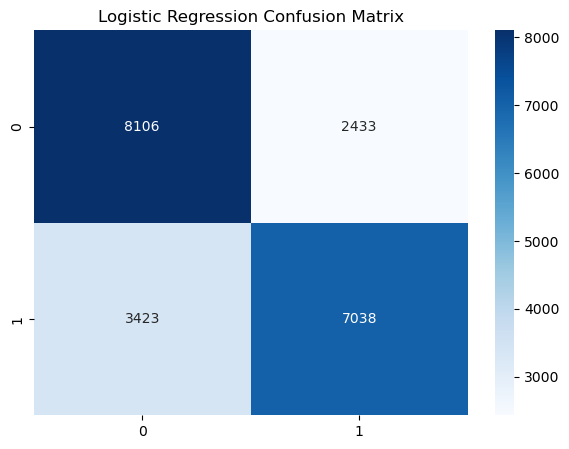

In [10]:
#confusion matrix 

plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test,logreg_pred), annot = True , fmt = 'd' , cmap = 'Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

In [11]:
from sklearn.neighbors import KNeighborsClassifier

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)

In [13]:
#display accuracy and peformance metrics

print(f'K-Nearest Neighbors Accuracy:{knn_accuracy * 100:.2f}')
print('\n K-Nearest Neighbors Classification Report :')
print(classification_report(y_test, knn_pred))

K-Nearest Neighbors Accuracy:62.74

 K-Nearest Neighbors Classification Report :
              precision    recall  f1-score   support

           0       0.62      0.65      0.64     10539
           1       0.63      0.60      0.62     10461

    accuracy                           0.63     21000
   macro avg       0.63      0.63      0.63     21000
weighted avg       0.63      0.63      0.63     21000



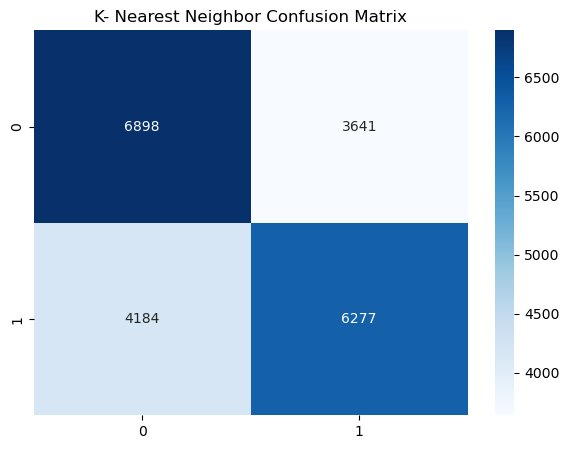

In [14]:
#confusion matrix 

plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test,knn_pred), annot = True , fmt = 'd' , cmap = 'Blues')
plt.title('K- Nearest Neighbor Confusion Matrix')
plt.show()

In [15]:
from sklearn.tree import DecisionTreeClassifier


In [16]:
#decision tree

decision_tree = DecisionTreeClassifier()
decision_tree.fit(X_train, y_train)
decision_tree_pred = decision_tree.predict(X_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_pred)

In [17]:
#display accuracy and peformance metrics

print(f'Decision Tree Accuracy:{knn_accuracy * 100:.2f}')
print('\n Decision Tree Classification Report :')
print(classification_report(y_test, decision_tree_pred))

Decision Tree Accuracy:62.74

 Decision Tree Classification Report :
              precision    recall  f1-score   support

           0       0.63      0.63      0.63     10539
           1       0.63      0.63      0.63     10461

    accuracy                           0.63     21000
   macro avg       0.63      0.63      0.63     21000
weighted avg       0.63      0.63      0.63     21000



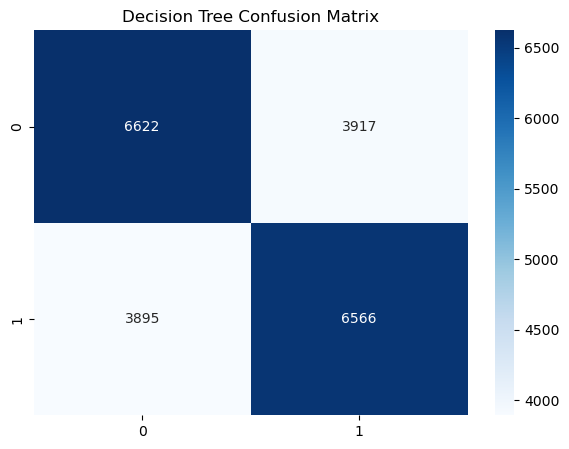

In [18]:
#confusion matrix 

plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test,decision_tree_pred), annot = True , fmt = 'd' , cmap = 'Blues')
plt.title('Decision Tree Confusion Matrix')
plt.show()

In [19]:
from sklearn.svm import SVC

In [20]:
svm = SVC()
svm.fit(X_train,y_train)
svm_pred = svm.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

In [21]:
print(f'Support Vector Machine Accuracy:{svm_accuracy * 100:.2f}')
print('\n Support Vector Machine Classification Report :')
print(classification_report(y_test, svm_pred))

Support Vector Machine Accuracy:72.43

 Support Vector Machine Classification Report :
              precision    recall  f1-score   support

           0       0.71      0.76      0.74     10539
           1       0.74      0.69      0.71     10461

    accuracy                           0.72     21000
   macro avg       0.73      0.72      0.72     21000
weighted avg       0.73      0.72      0.72     21000



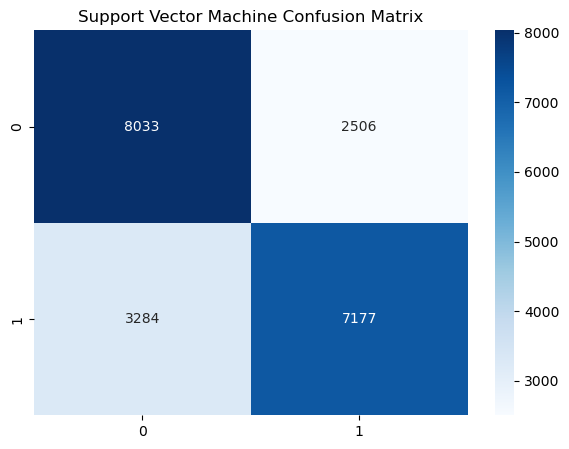

In [22]:
plt.figure(figsize = (7,5))
sns.heatmap(confusion_matrix(y_test,svm_pred), annot = True , fmt = 'd' , cmap = 'Blues')
plt.title('Support Vector Machine Confusion Matrix')
plt.show()

In [23]:
model_accuracies = {'Logistic Regression' : logreg_accuracy, 
                    'K-Nearest Neighbors' : knn_accuracy,
                    'Decision Tree' : decision_tree_accuracy,
                    'Support Vector Machine' : svm_accuracy}


for model,accuracy in model_accuracies.items() :
    print(f'{model} Accuracy : {accuracy * 100 : .2f} %')

Logistic Regression Accuracy :  72.11 %
K-Nearest Neighbors Accuracy :  62.74 %
Decision Tree Accuracy :  62.80 %
Support Vector Machine Accuracy :  72.43 %
